# Iran Synthetic Forecast Validation

Compare the synthetic Iran forecast (from `generate_iran_synthetic.py`) against real historical BigQuery data. For each data source / metric combination:

1. **Historical + Forecast**: Real BQ actuals overlaid with synthetic forecast from 2026-02-27 onward
2. **Diff**: Synthetic forecast minus real actuals (zero before 2/27 where both exist, diverges after)
3. **Forecast window**: Zoomed view from 2025-10-01 to 2026-12-31

In [19]:
# [setup]
import sys
import time

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from google.cloud import bigquery

# Constants
PROJECT = "moz-fx-data-bq-data-science"
SYNTHETIC_PATH = "/home/ext_brwells_mozilla_com/data/iran_synthetic/iran_synthetic.parquet"
IRAN_SHUTDOWN_DATE = pd.Timestamp("2026-02-27")
ZOOM_START = pd.Timestamp("2025-10-01")
ZOOM_END = pd.Timestamp("2026-12-31")

# All 12 Iran-only SQL queries, keyed by (platform, telemetry_source, metric).
# Filtered to country = 'IR' in WHERE clause. No mozaic_daily import needed.
IRAN_QUERIES = {
    ("desktop", "glean", "DAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(os_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(os_version) LIKE '%windows%' AND LOWER(os_version) NOT LIKE '%windows 10%' AND LOWER(os_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(dau) AS y,
     FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop" AND submission_date >= "2023-04-17" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "glean", "New Profiles"): """
    SELECT first_seen_date AS x, country,
           IFNULL(LOWER(windows_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(windows_version) LIKE '%windows%' AND LOWER(windows_version) NOT LIKE '%windows 10%' AND LOWER(windows_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(new_profiles) AS y,
     FROM `moz-fx-data-shared-prod.firefox_desktop.new_profiles_aggregates`
    WHERE is_desktop AND first_seen_date >= "2023-07-01" AND first_seen_date NOT BETWEEN "2023-07-18" AND "2023-07-19" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "glean", "Existing Engagement DAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows%' AND LOWER(normalized_os_version) NOT LIKE '%windows 10%' AND LOWER(normalized_os_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(dau) AS y,
     FROM `moz-fx-data-shared-prod.firefox_desktop.desktop_engagement_aggregates`
    WHERE is_desktop AND lifecycle_stage = "existing_user" AND submission_date >= "2023-06-07" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "glean", "Existing Engagement MAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows%' AND LOWER(normalized_os_version) NOT LIKE '%windows 10%' AND LOWER(normalized_os_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(mau) AS y,
     FROM `moz-fx-data-shared-prod.firefox_desktop.desktop_engagement_aggregates`
    WHERE is_desktop AND lifecycle_stage = "existing_user" AND submission_date >= "2023-06-07" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "legacy", "DAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(os_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(os_version) LIKE '%windows%' AND LOWER(os_version) NOT LIKE '%windows 10%' AND LOWER(os_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(dau) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop" AND submission_date >= "2020-01-01" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "legacy", "New Profiles"): """
    SELECT first_seen_date AS x, country,
           IFNULL(LOWER(windows_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(windows_version) LIKE '%windows%' AND LOWER(windows_version) NOT LIKE '%windows 10%' AND LOWER(windows_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(new_profiles) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.desktop_new_profiles`
    WHERE is_desktop AND first_seen_date >= "2021-01-01" AND first_seen_date NOT BETWEEN "2023-07-18" AND "2023-07-19" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "legacy", "Existing Engagement DAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows%' AND LOWER(normalized_os_version) NOT LIKE '%windows 10%' AND LOWER(normalized_os_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(dau) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.desktop_engagement`
    WHERE is_desktop AND lifecycle_stage = "existing_user" AND submission_date >= "2021-01-01" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("desktop", "legacy", "Existing Engagement MAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows 1%', FALSE) AS modern_windows,
           IFNULL(LOWER(normalized_os_version) LIKE '%windows%' AND LOWER(normalized_os_version) NOT LIKE '%windows 10%' AND LOWER(normalized_os_version) NOT LIKE '%windows 11%', FALSE) AS winX,
           SUM(mau) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.desktop_engagement`
    WHERE is_desktop AND lifecycle_stage = "existing_user" AND submission_date >= "2021-01-01" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("mobile", "glean", "DAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(app_name) LIKE '%fenix%', FALSE) AS fenix_android,
           IFNULL(LOWER(app_name) LIKE '%firefox ios%', FALSE) AS firefox_ios,
           IFNULL(LOWER(app_name) LIKE '%focus android%', FALSE) AS focus_android,
           IFNULL(LOWER(app_name) LIKE '%focus ios%', FALSE) AS focus_ios,
           SUM(dau) AS y,
     FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
    WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS") AND submission_date >= "2020-12-31" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("mobile", "glean", "New Profiles"): """
    SELECT first_seen_date AS x, country,
           IFNULL(LOWER(app_name) LIKE '%fenix%', FALSE) AS fenix_android,
           IFNULL(LOWER(app_name) LIKE '%firefox ios%', FALSE) AS firefox_ios,
           IFNULL(LOWER(app_name) LIKE '%focus android%', FALSE) AS focus_android,
           IFNULL(LOWER(app_name) LIKE '%focus ios%', FALSE) AS focus_ios,
           SUM(new_profiles) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.mobile_new_profiles`
    WHERE is_mobile AND first_seen_date >= "2023-07-01" AND first_seen_date NOT BETWEEN "2023-07-18" AND "2023-07-19" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("mobile", "glean", "Existing Engagement DAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(app_name) LIKE '%fenix%', FALSE) AS fenix_android,
           IFNULL(LOWER(app_name) LIKE '%firefox ios%', FALSE) AS firefox_ios,
           IFNULL(LOWER(app_name) LIKE '%focus android%', FALSE) AS focus_android,
           IFNULL(LOWER(app_name) LIKE '%focus ios%', FALSE) AS focus_ios,
           SUM(dau) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.mobile_engagement`
    WHERE is_mobile AND lifecycle_stage = "existing_user" AND submission_date >= "2023-07-01" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
    ("mobile", "glean", "Existing Engagement MAU"): """
    SELECT submission_date AS x, country,
           IFNULL(LOWER(app_name) LIKE '%fenix%', FALSE) AS fenix_android,
           IFNULL(LOWER(app_name) LIKE '%firefox ios%', FALSE) AS firefox_ios,
           IFNULL(LOWER(app_name) LIKE '%focus android%', FALSE) AS focus_android,
           IFNULL(LOWER(app_name) LIKE '%focus ios%', FALSE) AS focus_ios,
           SUM(mau) AS y,
     FROM `moz-fx-data-shared-prod.telemetry.mobile_engagement`
    WHERE is_mobile AND lifecycle_stage = "existing_user" AND submission_date >= "2023-07-01" AND country = 'IR'
    GROUP BY ALL
    ORDER BY 1, 2 ASC
    """,
}

# Plot styling
plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"Setup complete — {len(IRAN_QUERIES)} queries defined")

Setup complete — 12 queries defined


In [20]:
# [load-synthetic]
synthetic_df = pd.read_parquet(SYNTHETIC_PATH)
synthetic_df["x"] = pd.to_datetime(synthetic_df["x"])

# Aggregate across segments: sum y per (platform, telemetry_source, metric, date)
synthetic_agg = (
    synthetic_df
    .groupby(["platform", "telemetry_source", "metric", "x"], as_index=False)["y"]
    .sum()
)

print(f"Loaded synthetic parquet: {len(synthetic_df)} rows -> {len(synthetic_agg)} aggregated rows")
print(f"Date range: {synthetic_agg['x'].min().date()} to {synthetic_agg['x'].max().date()}")
print(f"Combos: {synthetic_agg.groupby(['platform','telemetry_source','metric']).ngroups}")

Loaded synthetic parquet: 26920 rows -> 8076 aggregated rows
Date range: 2026-02-27 to 2027-12-31
Combos: 12


In [21]:
synthetic_df

,x,country,y,modern_windows,winX,platform,telemetry_source,metric,fenix_android,firefox_ios,focus_android,focus_ios
0,2026-02-27,IR,4.365513e+05,True,False,desktop,glean,DAU,False,False,False,False
1,2026-02-27,IR,8.893060e+03,False,False,desktop,glean,DAU,False,False,False,False
2,2026-02-27,IR,6.011245e+04,False,True,desktop,glean,DAU,False,False,False,False
3,2026-02-28,IR,7.984369e+05,True,False,desktop,glean,DAU,False,False,False,False
4,2026-02-28,IR,1.172075e+04,False,False,desktop,glean,DAU,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
26915,2027-12-30,IR,-5.811325e+00,False,False,mobile,glean,Existing Engagement MAU,False,False,False,True
26916,2027-12-31,IR,1.890663e+06,False,False,mobile,glean,Existing Engagement MAU,True,False,False,False
26917,2027-12-31,IR,9.892447e+04,False,False,mobile,glean,Existing Engagement MAU,False,True,False,False
26918,2027-12-31,IR,-4.809120e+01,False,False,mobile,glean,Existing Engagement MAU,False,False,True,False


In [22]:
# [query-bq]
# Query BigQuery for Iran-only historical data across all 12 specs.
# Each query returns per-segment rows; we aggregate to total IR per date.

client = bigquery.Client(project=PROJECT)

historical = {}  # key: (platform, telemetry_source, metric) -> DataFrame with columns [x, y]
total_queries = len(IRAN_QUERIES)
overall_start = time.time()

for i, (key, sql) in enumerate(IRAN_QUERIES.items(), 1):
    platform, source, metric = key
    label = f"{platform.capitalize()} {source.capitalize()} {metric}"

    t0 = time.time()
    raw = client.query(sql).to_dataframe()
    elapsed = time.time() - t0
    total_elapsed = time.time() - overall_start

    # Aggregate across segments: sum y per date
    agg = raw.groupby("x", as_index=False)["y"].sum()
    agg["x"] = pd.to_datetime(agg["x"])
    agg = agg.sort_values("x")
    historical[key] = agg

    sys.stdout.write(
        f"[{i}/{total_queries}] {label}: "
        f"{len(raw)} raw rows -> {len(agg)} dates | "
        f"{elapsed:.1f}s | Total {total_elapsed:.0f}s\n"
    )
    sys.stdout.flush()

print(f"\nAll queries complete in {time.time() - overall_start:.0f}s")

[1/12] Desktop Glean DAU: 3231 raw rows -> 1077 dates | 8.1s | Total 8s
[2/12] Desktop Glean New Profiles: 2997 raw rows -> 999 dates | 5.0s | Total 13s
[3/12] Desktop Glean Existing Engagement DAU: 3075 raw rows -> 1025 dates | 4.8s | Total 18s
[4/12] Desktop Glean Existing Engagement MAU: 3075 raw rows -> 1025 dates | 3.5s | Total 21s
[5/12] Desktop Legacy DAU: 6834 raw rows -> 2278 dates | 7.8s | Total 29s
[6/12] Desktop Legacy New Profiles: 5731 raw rows -> 1911 dates | 3.6s | Total 33s
[7/12] Desktop Legacy Existing Engagement DAU: 5736 raw rows -> 1912 dates | 5.1s | Total 38s
[8/12] Desktop Legacy Existing Engagement MAU: 5736 raw rows -> 1912 dates | 4.0s | Total 42s
[9/12] Mobile Glean DAU: 7319 raw rows -> 1913 dates | 8.1s | Total 50s
[10/12] Mobile Glean New Profiles: 3720 raw rows -> 999 dates | 6.4s | Total 56s
[11/12] Mobile Glean Existing Engagement DAU: 4004 raw rows -> 1001 dates | 6.5s | Total 63s
[12/12] Mobile Glean Existing Engagement MAU: 4004 raw rows -> 1001 da

In [23]:
# [build-combined]
# Merge historical and synthetic into a single DataFrame for easy plotting.

rows = []
for (platform, source, metric), hist_df in historical.items():
    # Historical actuals
    for _, row in hist_df.iterrows():
        rows.append({
            "platform": platform,
            "telemetry_source": source,
            "metric": metric,
            "x": row["x"],
            "actual_y": row["y"],
        })

hist_all = pd.DataFrame(rows)

# Merge with synthetic forecast
combined = hist_all.merge(
    synthetic_agg.rename(columns={"y": "forecast_y"}),
    on=["platform", "telemetry_source", "metric", "x"],
    how="outer",
)
combined = combined.sort_values(["platform", "telemetry_source", "metric", "x"])

# Compute diff where both exist
combined["diff"] = combined["forecast_y"] - combined["actual_y"]

# Build a label column for plot titles
combined["label"] = (
    combined["platform"].str.capitalize() + " " +
    combined["telemetry_source"].str.capitalize() + " — " +
    combined["metric"]
)

COMBO_LABELS = combined.groupby(
    ["platform", "telemetry_source", "metric"]
)["label"].first().to_dict()

print(f"Combined DataFrame: {len(combined)} rows, {len(COMBO_LABELS)} combos")

Combined DataFrame: 24779 rows, 12 combos


## 1. Historical Actuals + Synthetic Forecast

Full time range. Blue = real BQ data, orange = synthetic forecast. Red dashed line = Iran shutdown date (2026-02-27).

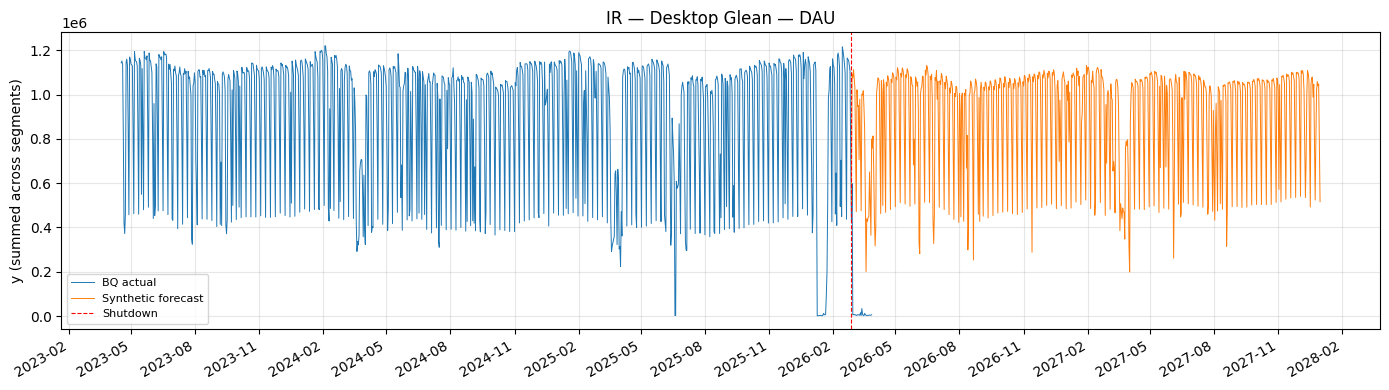

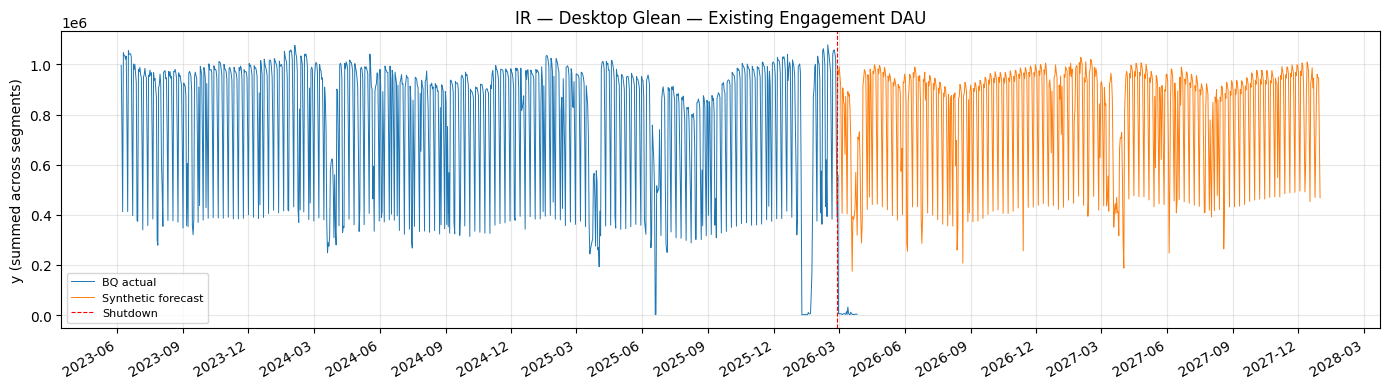

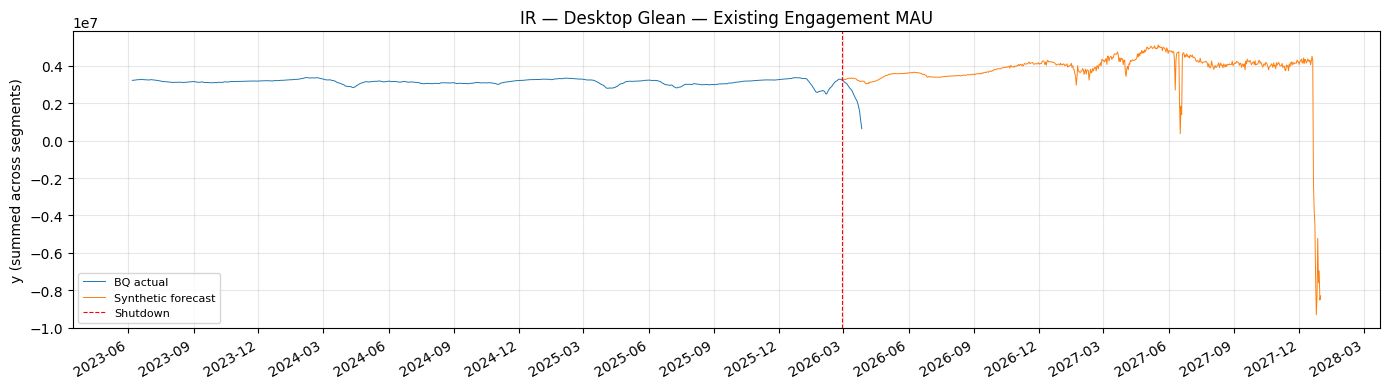

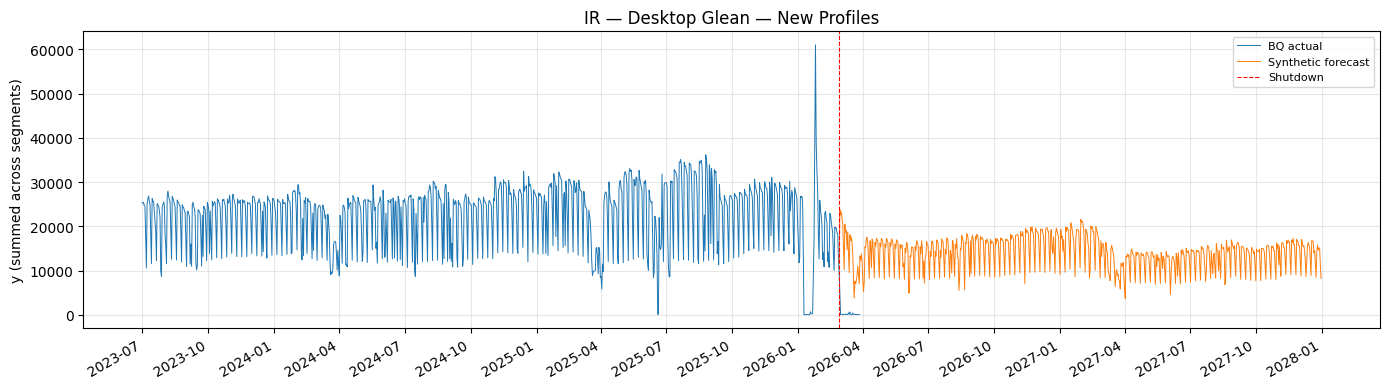

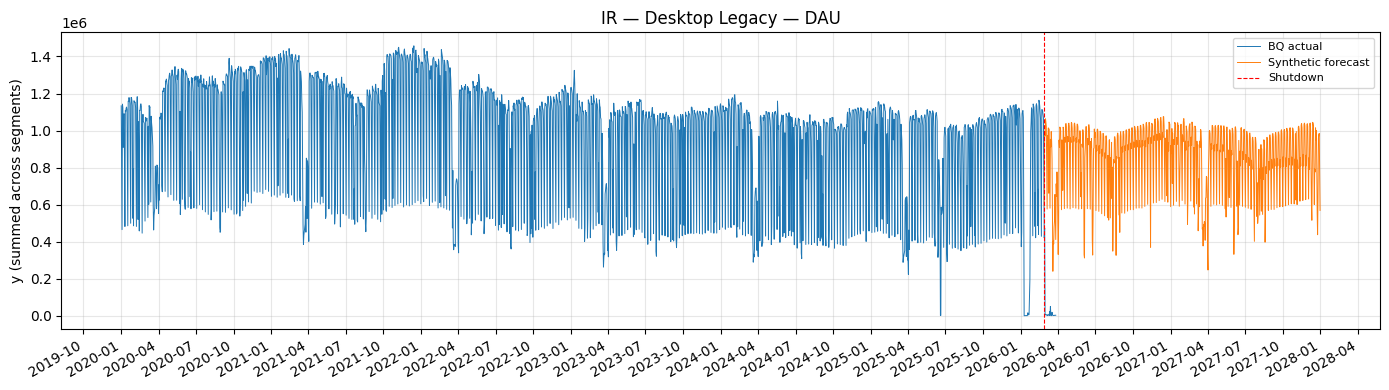

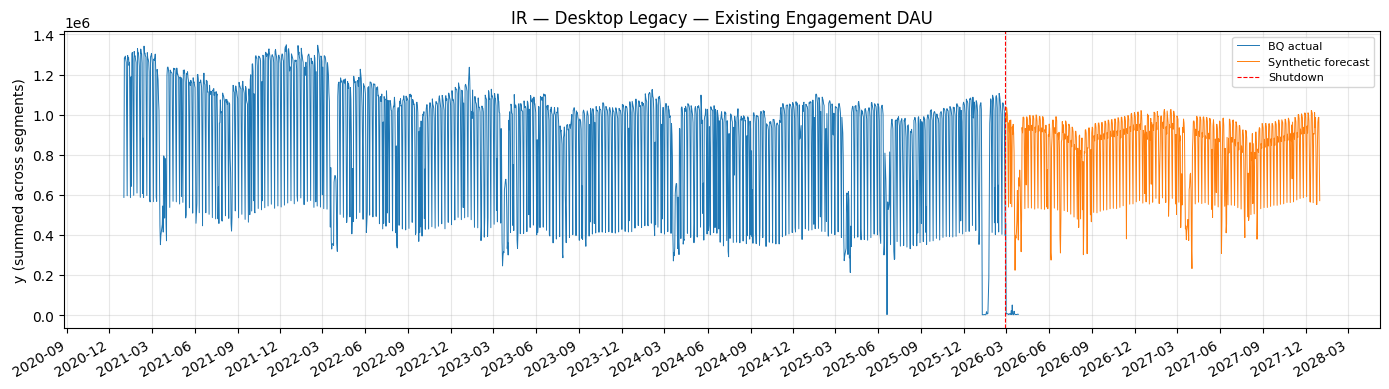

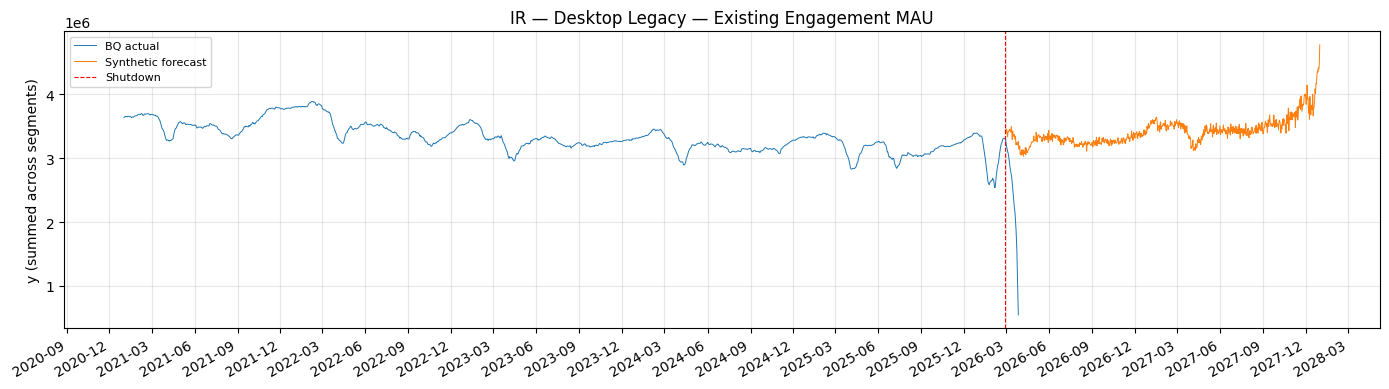

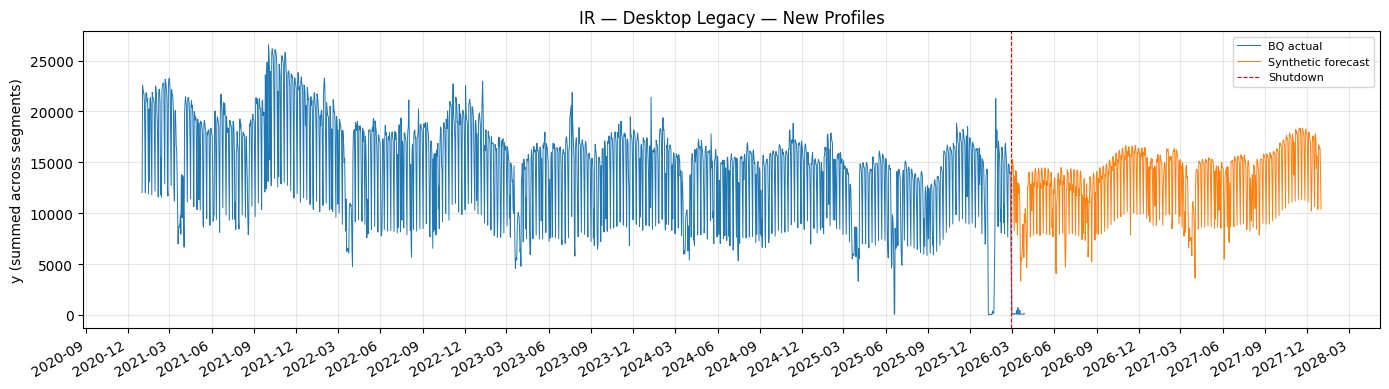

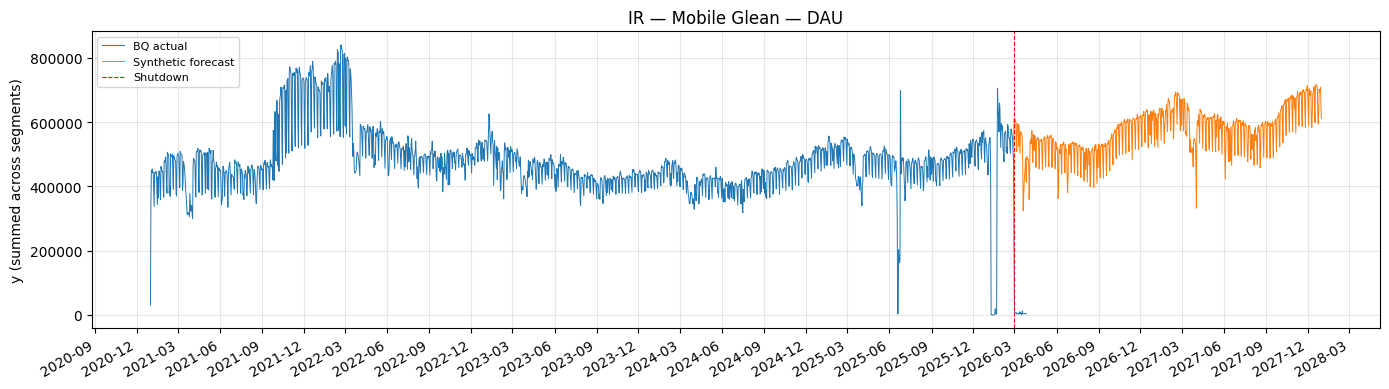

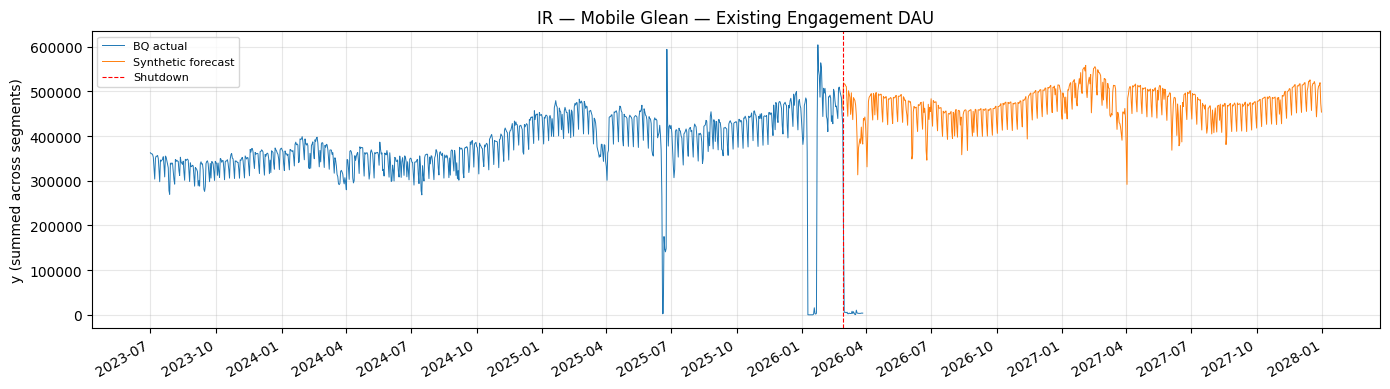

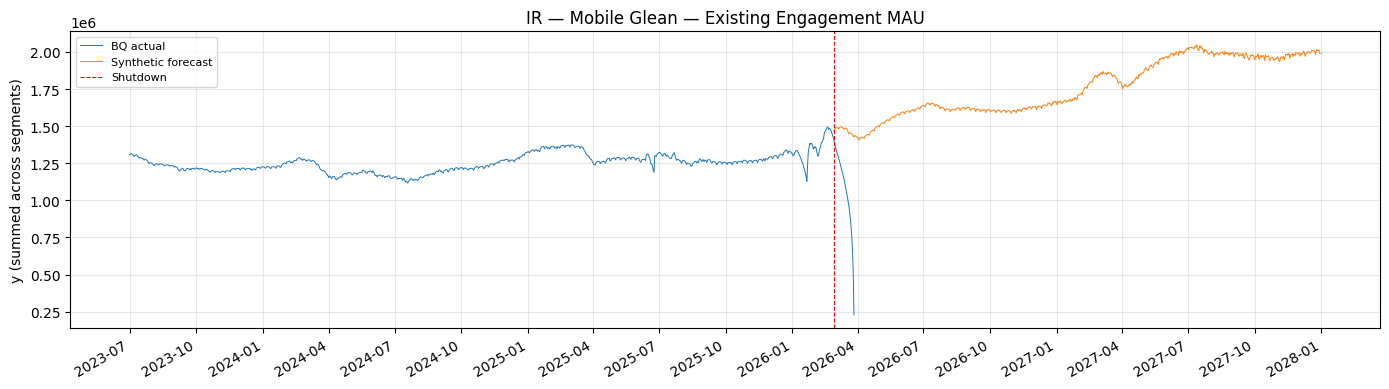

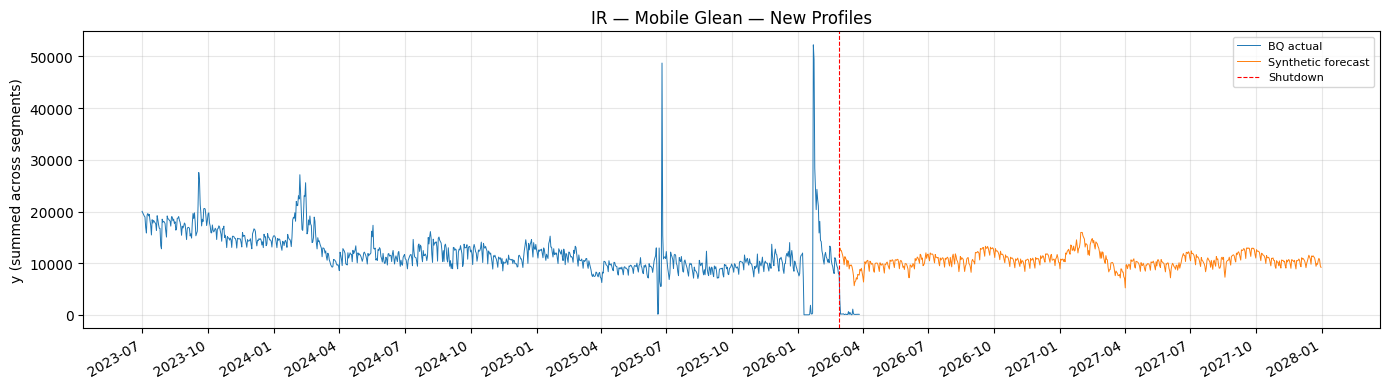

In [24]:
# [plot-overlay]
for key, label in COMBO_LABELS.items():
    platform, source, metric = key
    grp = combined[
        (combined["platform"] == platform)
        & (combined["telemetry_source"] == source)
        & (combined["metric"] == metric)
    ]

    fig, ax = plt.subplots()
    ax.plot(grp["x"], grp["actual_y"], linewidth=0.7, label="BQ actual", color="tab:blue")
    ax.plot(grp["x"], grp["forecast_y"], linewidth=0.7, label="Synthetic forecast", color="tab:orange")
    ax.axvline(IRAN_SHUTDOWN_DATE, color="red", linestyle="--", linewidth=0.8, label="Shutdown")
    ax.set_title(f"IR — {label}")
    ax.set_ylabel("y (summed across segments)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
# [plot-moving-avg]
# 28-day moving average. For the forecast series, we prepend the last 27 days
# of historical data so the rolling window is seeded from real actuals — as if
# the forecast is a seamless continuation of the historical series.

MA_WINDOW = 28

for key, label in COMBO_LABELS.items():
    platform, source, metric = key
    grp = combined[
        (combined["platform"] == platform)
        & (combined["telemetry_source"] == source)
        & (combined["metric"] == metric)
    ].sort_values("x")

    # Historical MA — straightforward
    hist = grp.dropna(subset=["actual_y"])[["x", "actual_y"]].copy()
    hist["actual_ma"] = hist["actual_y"].rolling(MA_WINDOW, min_periods=MA_WINDOW).mean()

    # Forecast MA — prepend tail of historical so the first 27 forecast days
    # have real data feeding into their rolling window
    forecast_only = grp.dropna(subset=["forecast_y"])[["x", "forecast_y"]].copy()
    if forecast_only.empty:
        continue

    hist_tail = hist[hist["x"] < forecast_only["x"].min()].tail(MA_WINDOW - 1)
    forecast_with_seed = pd.concat([
        hist_tail.rename(columns={"actual_y": "forecast_y"}).drop(columns=["actual_ma"], errors="ignore"),
        forecast_only,
    ], ignore_index=True).sort_values("x")
    forecast_with_seed["forecast_ma"] = (
        forecast_with_seed["forecast_y"]
        .rolling(MA_WINDOW, min_periods=MA_WINDOW)
        .mean()
    )
    # Drop the seed rows so we only plot from the forecast start onward
    forecast_ma = forecast_with_seed[
        forecast_with_seed["x"] >= forecast_only["x"].min()
    ]

    fig, ax = plt.subplots()
    ax.plot(hist["x"], hist["actual_ma"], linewidth=1.0, label=f"BQ actual ({MA_WINDOW}d MA)", color="tab:blue")
    ax.plot(forecast_ma["x"], forecast_ma["forecast_ma"], linewidth=1.0, label=f"Synthetic forecast ({MA_WINDOW}d MA)", color="tab:orange")
    ax.axvline(IRAN_SHUTDOWN_DATE, color="red", linestyle="--", linewidth=0.8, label="Shutdown")
    ax.set_title(f"{MA_WINDOW}-day Moving Average — IR — {label}")
    ax.set_ylabel("y (28d MA, summed across segments)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

## 2. Diff (Synthetic Forecast − BQ Actual)

Should be near zero before 2026-02-27 (no synthetic data exists there, so diff is NaN/absent), then diverges as actual Iran data drops to zero post-shutdown while the forecast continues.

In [ ]:
# [plot-diff]
for key, label in COMBO_LABELS.items():
    platform, source, metric = key
    grp = combined[
        (combined["platform"] == platform)
        & (combined["telemetry_source"] == source)
        & (combined["metric"] == metric)
    ]
    # Only plot where both series exist (diff is not NaN)
    diff_data = grp.dropna(subset=["diff"])

    if diff_data.empty:
        print(f"  {label}: no overlapping dates, skipping diff plot")
        continue

    fig, ax = plt.subplots()
    ax.plot(diff_data["x"], diff_data["diff"], linewidth=0.7, color="tab:green")
    ax.axvline(IRAN_SHUTDOWN_DATE, color="red", linestyle="--", linewidth=0.8, label="Shutdown")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="-")
    ax.set_title(f"Diff (forecast − actual) — IR — {label}")
    ax.set_ylabel("forecast_y − actual_y")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

## 3. Forecast Window (2025-10-01 to 2026-12-31)

Zoomed view showing ~5 months of real data leading into the shutdown, then the synthetic forecast continuing forward.

In [ ]:
# [plot-zoom]
for key, label in COMBO_LABELS.items():
    platform, source, metric = key
    grp = combined[
        (combined["platform"] == platform)
        & (combined["telemetry_source"] == source)
        & (combined["metric"] == metric)
    ]
    zoom = grp[(grp["x"] >= ZOOM_START) & (grp["x"] <= ZOOM_END)]

    fig, ax = plt.subplots()
    ax.plot(zoom["x"], zoom["actual_y"], linewidth=0.9, label="BQ actual", color="tab:blue")
    ax.plot(zoom["x"], zoom["forecast_y"], linewidth=0.9, label="Synthetic forecast", color="tab:orange")
    ax.axvline(IRAN_SHUTDOWN_DATE, color="red", linestyle="--", linewidth=0.8, label="Shutdown")
    ax.set_title(f"Forecast window — IR — {label}")
    ax.set_ylabel("y (summed across segments)")
    ax.set_xlim(ZOOM_START, ZOOM_END)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()